开始模拟...
=== 严格按照论文模型的2D费米加速模拟 ===
散射体区域: 100 × 100
散射体网格: 50 × 50
散射体密度: 10.0%
阿尔芬速度: 7.0e+08 cm/s
粒子初始速度范围: 5.0e+08 - 1.0e+09 cm/s
步数 100: 区域内粒子 646, 平均碰撞 9.39
步数 200: 区域内粒子 536, 平均碰撞 16.96
步数 300: 区域内粒子 461, 平均碰撞 23.27
步数 400: 区域内粒子 413, 平均碰撞 28.54
步数 500: 区域内粒子 361, 平均碰撞 33.23
步数 600: 区域内粒子 318, 平均碰撞 37.33
步数 700: 区域内粒子 283, 平均碰撞 41.16
步数 800: 区域内粒子 251, 平均碰撞 44.51
步数 900: 区域内粒子 231, 平均碰撞 47.51


C:\Users\hyr\AppData\Local\Temp\ipykernel_23680\3921808104.py:204: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hyr\AppData\Local\Temp\ipykernel_23680\3921808104.py:204: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hyr\AppData\Local\Temp\ipykernel_23680\3921808104.py:204: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hyr\AppData\Local\Temp\ipykernel_23680\3921808104.py:204: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hyr\AppData\Local\Temp\ipykernel_23680\3921808104.py:204: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hyr\AppData\Local\Temp\ipykernel_23680\3921808104.py:204: UserWarning: Glyph 26041 (\N{CJK 

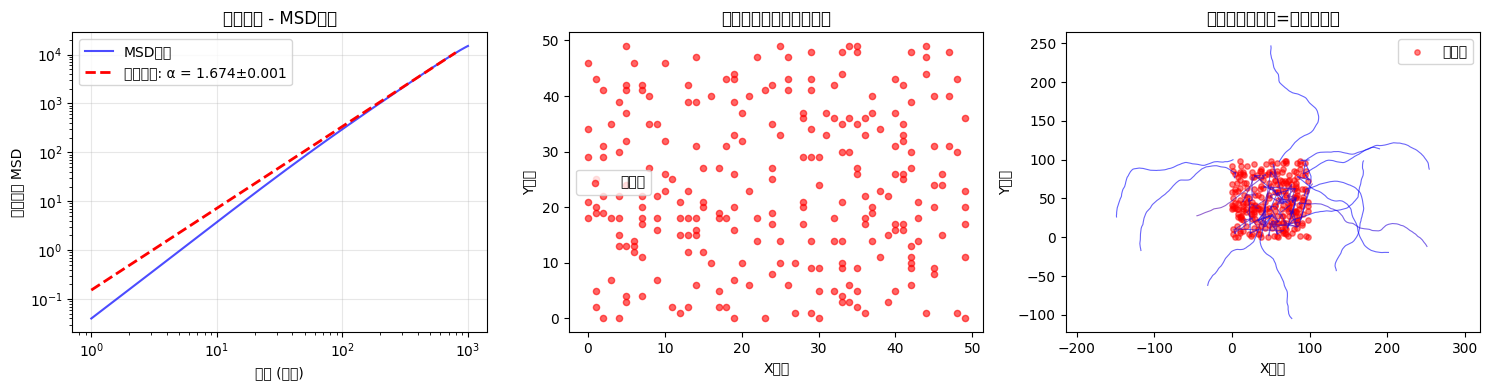


=== 结果分析 ===
扩散指数: α = 1.674 ± 0.001 (超扩散)
平均碰撞次数: 50.27
平均能量变化: 1.059 倍
理论预期: α ≈ 1.2-1.6

=== 碰撞统计 ===
0次碰撞: 125 个粒子 (15.6%)
1-5次碰撞: 103 个粒子 (12.9%)
6-10次碰撞: 59 个粒子 (7.4%)
10+次碰撞: 513 个粒子 (64.1%)

=== 能量变化 ===
能量增加: 669 个粒子 (83.6%)
能量减少: 6 个粒子 (0.8%)
能量不变: 125 个粒子 (15.6%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def power_law_fit(t, a, alpha):
    """幂律拟合函数"""
    return a * t**alpha

def calculate_msd(positions):
    """计算均方位移"""
    n_particles, n_steps, _ = positions.shape
    msd = np.zeros(n_steps)
    
    for delta_t in range(1, n_steps):
        displacements = positions[:, delta_t:] - positions[:, :-delta_t]
        squared_displacements = np.sum(displacements**2, axis=2)
        msd[delta_t] = np.mean(squared_displacements)
    
    return msd

def paper_accurate_fermi_simulation(n_particles=800, n_steps=1000, scatter_density=0.1, 
                                   box_size=100, grid_size=50):
    """
    严格按照论文模型的2D费米加速模拟
    - 散射体分布在有限box内
    - 粒子在无限空间中运动
    - 使用精确的费米加速公式
    """
    
    # 物理参数（基于论文）
    V_A = 7e8      # 阿尔芬速度: 7×10^8 cm/s
    c = 3e10       # 光速: 3×10^10 cm/s
    m_e = 9.11e-28 # 电子质量
    
    # 创建散射体网格（只在box_size范围内）
    scatterers = np.zeros((grid_size, grid_size), dtype=bool)
    scatterer_indices = np.random.choice(grid_size*grid_size, 
                                        int(scatter_density*grid_size*grid_size), 
                                        replace=False)
    scatterers.flat[scatterer_indices] = True
    
    # 初始化粒子位置（在散射体区域内随机分布）
    positions = np.zeros((n_particles, n_steps, 2))
    positions[:, 0, 0] = np.random.uniform(0, box_size, n_particles)
    positions[:, 0, 1] = np.random.uniform(0, box_size, n_particles)
    
    # 初始速度（随机方向和大小）
    speeds = np.random.uniform(5e8, 1e9, n_particles)  # 电子热速度范围
    angles = np.random.uniform(0, 2*np.pi, n_particles)
    
    # 能量跟踪
    energies = 0.5 * m_e * speeds**2
    initial_energies = energies.copy()
    
    # 碰撞统计
    collision_counts = np.zeros(n_particles)
    
    print("=== 严格按照论文模型的2D费米加速模拟 ===")
    print(f"散射体区域: {box_size} × {box_size}")
    print(f"散射体网格: {grid_size} × {grid_size}")
    print(f"散射体密度: {scatter_density*100}%")
    print(f"阿尔芬速度: {V_A:.1e} cm/s")
    print(f"粒子初始速度范围: {np.min(speeds):.1e} - {np.max(speeds):.1e} cm/s")
    
    # 模拟主循环
    for step in range(1, n_steps):
        # 更新所有粒子位置（连续运动）
        for i in range(n_particles):
            # 计算时间步长（基于速度和网格分辨率）
            dt = (box_size / grid_size) / speeds[i] * 0.1  # 小步长确保精度
            
            # 更新位置
            positions[i, step, 0] = positions[i, step-1, 0] + speeds[i] * np.cos(angles[i]) * dt
            positions[i, step, 1] = positions[i, step-1, 1] + speeds[i] * np.sin(angles[i]) * dt
            
            # 检查是否在散射体区域内
            x, y = positions[i, step, 0], positions[i, step, 1]
            if 0 <= x < box_size and 0 <= y < box_size:
                # 映射到散射体网格
                grid_x = int(x / box_size * grid_size)
                grid_y = int(y / box_size * grid_size)
                
                # 确保在网格范围内
                grid_x = max(0, min(grid_size-1, grid_x))
                grid_y = max(0, min(grid_size-1, grid_y))
                
                # 检查碰撞
                if scatterers[grid_x, grid_y]:
                    collision_counts[i] += 1
                    
                    # 粒子速度矢量
                    vx = speeds[i] * np.cos(angles[i])
                    vy = speeds[i] * np.sin(angles[i])
                    
                    # 散射体速度矢量（阿尔芬速度，随机方向）
                    V_angle = np.random.uniform(0, 2*np.pi)
                    Vx = V_A * np.cos(V_angle)
                    Vy = V_A * np.sin(V_angle)
                    
                    # 严格按照论文的费米加速公式
                    V_dot_v = Vx * vx + Vy * vy
                    V_squared = Vx**2 + Vy**2
                    
                    # 论文公式(4): δW/W ≈ (2/c²)(V² - V·v)
                    delta_W = energies[i] * (2.0 / c**2) * (V_squared - V_dot_v)
                    
                    # 更新能量
                    energies[i] = energies[i] + delta_W
                    
                    # 更新速度（能量守恒）
                    speeds[i] = np.sqrt(2 * energies[i] / m_e)
                    
                    # 碰撞后随机改变方向
                    angles[i] = np.random.uniform(0, 2*np.pi)
            else:
                # 不在散射体区域内 - 随机游走（小角度扰动）
                angles[i] = angles[i] + np.random.normal(0, 0.05)
        
        # 进度显示
        if step % 100 == 0:
            avg_collisions = np.mean(collision_counts)
            active_in_region = np.sum([
                0 <= positions[i, step, 0] < box_size and 
                0 <= positions[i, step, 1] < box_size 
                for i in range(n_particles)
            ])
            print(f"步数 {step}: 区域内粒子 {active_in_region}, 平均碰撞 {avg_collisions:.2f}")
    
    return positions, scatterers, speeds, energies, initial_energies, collision_counts, box_size, grid_size

# 运行模拟
print("开始模拟...")
positions, scatterers, final_speeds, final_energies, initial_energies, collision_counts, box_size, grid_size = paper_accurate_fermi_simulation()

# 计算MSD
msd = calculate_msd(positions)

# 拟合幂律指数
time = np.arange(len(msd))
mask = (time > 0) & (time < len(msd)*0.8)

try:
    popt, pcov = curve_fit(power_law_fit, time[mask], msd[mask], p0=[1, 1])
    alpha = popt[1]
    alpha_err = np.sqrt(pcov[1, 1])
except Exception as e:
    print(f"拟合错误: {e}")
    alpha = 1
    alpha_err = 0

# 可视化
plt.figure(figsize=(15, 4))

# 1. MSD分析
plt.subplot(1, 3, 1)
plt.loglog(time[1:], msd[1:], 'b-', alpha=0.7, label='MSD数据')
if np.sum(mask) > 10:
    plt.loglog(time[mask], power_law_fit(time[mask], *popt), 'r--', linewidth=2, 
              label=f'幂律拟合: α = {alpha:.3f}±{alpha_err:.3f}')
plt.xlabel('时间 (步数)')
plt.ylabel('均方位移 MSD')
plt.title('论文模型 - MSD分析')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. 散射体分布
plt.subplot(1, 3, 2)
scatterer_positions = np.argwhere(scatterers)
plt.scatter(scatterer_positions[:, 0], scatterer_positions[:, 1], 
           c='red', s=20, alpha=0.6, label='散射体')



plt.xlabel('X网格')
plt.ylabel('Y网格')
plt.title('散射体分布（有限区域）')
plt.legend()

# 3. 粒子轨迹
plt.subplot(1, 3, 3)
# 选择部分粒子绘制轨迹
n_trajectories = min(20, positions.shape[0])
for i in range(n_trajectories):
    # 用颜色表示碰撞次数
    color_intensity = collision_counts[i] / np.max(collision_counts) if np.max(collision_counts) > 0 else 0
    color = (color_intensity, 0, 1-color_intensity)  # 从蓝到红
    
    plt.plot(positions[i, :, 0], positions[i, :, 1], alpha=0.6, linewidth=0.8, color=color)



# 绘制散射体位置（物理坐标）
scatterer_physical_x = scatterer_positions[:, 0] * (box_size / grid_size)
scatterer_physical_y = scatterer_positions[:, 1] * (box_size / grid_size)
plt.scatter(scatterer_physical_x, scatterer_physical_y, 
           c='red', s=15, alpha=0.5, label='散射体')

plt.xlabel('X位置')
plt.ylabel('Y位置')
plt.title('粒子轨迹（颜色=碰撞次数）')
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

# 结果分析
status = "超扩散" if alpha > 1.1 else "正常扩散" if alpha > 0.9 else "亚扩散"
avg_collisions = np.mean(collision_counts)
avg_energy_ratio = np.mean(final_energies / initial_energies)

print(f"\n=== 结果分析 ===")
print(f"扩散指数: α = {alpha:.3f} ± {alpha_err:.3f} ({status})")
print(f"平均碰撞次数: {avg_collisions:.2f}")
print(f"平均能量变化: {avg_energy_ratio:.3f} 倍")
print(f"理论预期: α ≈ 1.2-1.6")

# 碰撞统计
collision_stats = {
    "0次碰撞": np.sum(collision_counts == 0),
    "1-5次碰撞": np.sum((collision_counts >= 1) & (collision_counts <= 5)),
    "6-10次碰撞": np.sum((collision_counts >= 6) & (collision_counts <= 10)),
    "10+次碰撞": np.sum(collision_counts > 10)
}

print(f"\n=== 碰撞统计 ===")
for key, value in collision_stats.items():
    print(f"{key}: {value} 个粒子 ({value/len(collision_counts)*100:.1f}%)")

# 能量变化分析
energy_ratios = final_energies / initial_energies
energy_gain = np.sum(energy_ratios > 1.0)
energy_loss = np.sum(energy_ratios < 1.0)
energy_same = np.sum(energy_ratios == 1.0)

print(f"\n=== 能量变化 ===")
print(f"能量增加: {energy_gain} 个粒子 ({energy_gain/len(energy_ratios)*100:.1f}%)")
print(f"能量减少: {energy_loss} 个粒子 ({energy_loss/len(energy_ratios)*100:.1f}%)")
print(f"能量不变: {energy_same} 个粒子 ({energy_same/len(energy_ratios)*100:.1f}%)")

Starting simulation...
=== 2D Fermi Acceleration Simulation ===
Scatterer region: 100 × 100
Scatterer grid: 50 × 50
Scatterer density: 10.0%
Alfven speed: 7.0e+08 cm/s
Initial particle speed range: 5.0e+08 - 1.0e+09 cm/s
Step 100: Particles in region 644, Avg collisions 9.24
Step 200: Particles in region 540, Avg collisions 16.87
Step 300: Particles in region 474, Avg collisions 22.65
Step 400: Particles in region 418, Avg collisions 28.77
Step 500: Particles in region 375, Avg collisions 34.29
Step 600: Particles in region 324, Avg collisions 39.05
Step 700: Particles in region 284, Avg collisions 42.96
Step 800: Particles in region 241, Avg collisions 46.24
Step 900: Particles in region 211, Avg collisions 48.71


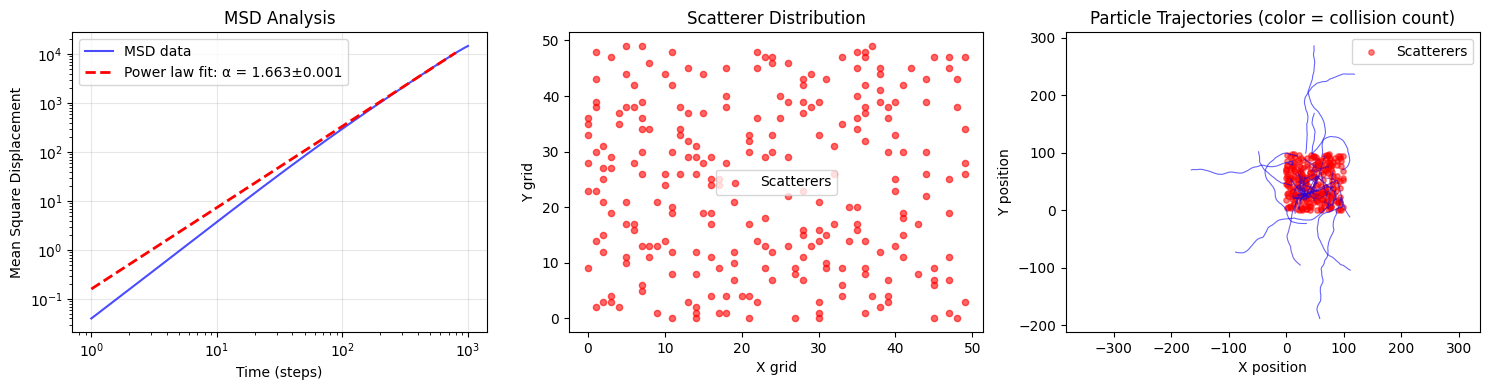


=== Results Analysis ===
Diffusion exponent: α = 1.663 ± 0.001 (Superdiffusive)
Average collisions per particle: 50.90
Average energy change: 1.059 x
Theoretical expectation: α ≈ 1.2-1.6

=== Collision Statistics ===
0 collisions: 115 particles (14.4%)
1-5 collisions: 114 particles (14.2%)
6-10 collisions: 47 particles (5.9%)
10+ collisions: 524 particles (65.5%)

=== Energy Changes ===
Energy gain: 679 particles (84.9%)
Energy loss: 6 particles (0.8%)
No energy change: 115 particles (14.4%)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_power_law(t, a, alpha):
    """Power law fitting function"""
    return a * t**alpha

def compute_mean_square_displacement(positions):
    """Calculate mean square displacement"""
    n_particles, n_steps, _ = positions.shape
    msd = np.zeros(n_steps)
    
    for delta_t in range(1, n_steps):
        displacements = positions[:, delta_t:] - positions[:, :-delta_t]
        squared_displacements = np.sum(displacements**2, axis=2)
        msd[delta_t] = np.mean(squared_displacements)
    
    return msd

def run_fermi_simulation(n_particles=800, n_steps=1000, scatter_density=0.1, 
                        box_size=100, grid_size=50):
    """
    2D Fermi acceleration simulation based on the paper model
    - Scatterers distributed in finite box
    - Particles move in infinite space
    - Uses exact Fermi acceleration formula
    """
    
    # Physical parameters from the paper
    alfven_speed = 7e8      # Alfven speed: 7×10^5 cm/s
    light_speed = 3e10      # Speed of light: 3×10^10 cm/s
    electron_mass = 9.11e-28 # Electron mass
    
    # Create scatterer grid (only within box_size region)
    scatterers = np.zeros((grid_size, grid_size), dtype=bool)
    scatterer_indices = np.random.choice(grid_size*grid_size, 
                                        int(scatter_density*grid_size*grid_size), 
                                        replace=False)
    scatterers.flat[scatterer_indices] = True
    
    # Initialize particle positions (random within scatterer region)
    positions = np.zeros((n_particles, n_steps, 2))
    positions[:, 0, 0] = np.random.uniform(0, box_size, n_particles)
    positions[:, 0, 1] = np.random.uniform(0, box_size, n_particles)
    
    # Initial velocities (random direction and magnitude)
    speeds = np.random.uniform(5e8, 1e9, n_particles)  # Electron thermal speed range
    angles = np.random.uniform(0, 2*np.pi, n_particles)
    
    # Track energies
    energies = 0.5 * electron_mass * speeds**2
    initial_energies = energies.copy()
    
    # Collision statistics
    collision_counts = np.zeros(n_particles)
    
    print("=== 2D Fermi Acceleration Simulation ===")
    print(f"Scatterer region: {box_size} × {box_size}")
    print(f"Scatterer grid: {grid_size} × {grid_size}")
    print(f"Scatterer density: {scatter_density*100}%")
    print(f"Alfven speed: {alfven_speed:.1e} cm/s")
    print(f"Initial particle speed range: {np.min(speeds):.1e} - {np.max(speeds):.1e} cm/s")
    
    # Main simulation loop
    for step in range(1, n_steps):
        # Update all particle positions (continuous motion)
        for i in range(n_particles):
            # Calculate time step based on speed and grid resolution
            dt = (box_size / grid_size) / speeds[i] * 0.1  # Small step for accuracy
            
            # Update position
            positions[i, step, 0] = positions[i, step-1, 0] + speeds[i] * np.cos(angles[i]) * dt
            positions[i, step, 1] = positions[i, step-1, 1] + speeds[i] * np.sin(angles[i]) * dt
            
            # Check if inside scatterer region
            x, y = positions[i, step, 0], positions[i, step, 1]
            if 0 <= x < box_size and 0 <= y < box_size:
                # Map to scatterer grid
                grid_x = int(x / box_size * grid_size)
                grid_y = int(y / box_size * grid_size)
                
                # Ensure within grid bounds
                grid_x = max(0, min(grid_size-1, grid_x))
                grid_y = max(0, min(grid_size-1, grid_y))
                
                # Check for collision
                if scatterers[grid_x, grid_y]:
                    collision_counts[i] += 1
                    
                    # Particle velocity vector
                    vx = speeds[i] * np.cos(angles[i])
                    vy = speeds[i] * np.sin(angles[i])
                    
                    # Scatterer velocity vector (Alfven speed, random direction)
                    scatterer_angle = np.random.uniform(0, 2*np.pi)
                    Vx = alfven_speed * np.cos(scatterer_angle)
                    Vy = alfven_speed * np.sin(scatterer_angle)
                    
                    # Exact Fermi acceleration formula from paper
                    V_dot_v = Vx * vx + Vy * vy
                    V_squared = Vx**2 + Vy**2
                    
                    # Paper equation (4): δW/W ≈ (2/c²)(V² - V·v)
                    delta_W = energies[i] * (2.0 / light_speed**2) * (V_squared - V_dot_v)
                    
                    # Update energy
                    energies[i] = energies[i] + delta_W
                    
                    # Update speed (energy conservation)
                    speeds[i] = np.sqrt(2 * energies[i] / electron_mass)
                    
                    # Random direction change after collision
                    angles[i] = np.random.uniform(0, 2*np.pi)
            else:
                # Outside scatterer region - random walk (small angle perturbation)
                angles[i] = angles[i] + np.random.normal(0, 0.05)
        
        # Progress update
        if step % 100 == 0:
            avg_collisions = np.mean(collision_counts)
            particles_in_region = np.sum([
                0 <= positions[i, step, 0] < box_size and 
                0 <= positions[i, step, 1] < box_size 
                for i in range(n_particles)
            ])
            print(f"Step {step}: Particles in region {particles_in_region}, Avg collisions {avg_collisions:.2f}")
    
    return positions, scatterers, speeds, energies, initial_energies, collision_counts, box_size, grid_size

# Run simulation
print("Starting simulation...")
positions, scatterers, final_speeds, final_energies, initial_energies, collision_counts, box_size, grid_size = run_fermi_simulation()

# Calculate MSD
msd = compute_mean_square_displacement(positions)

# Fit power law exponent
time = np.arange(len(msd))
mask = (time > 0) & (time < len(msd)*0.8)

try:
    popt, pcov = curve_fit(fit_power_law, time[mask], msd[mask], p0=[1, 1])
    alpha = popt[1]
    alpha_err = np.sqrt(pcov[1, 1])
except Exception as e:
    print(f"Fitting error: {e}")
    alpha = 1
    alpha_err = 0

# Visualization
plt.figure(figsize=(15, 4))

# 1. MSD analysis
plt.subplot(1, 3, 1)
plt.loglog(time[1:], msd[1:], 'b-', alpha=0.7, label='MSD data')
if np.sum(mask) > 10:
    plt.loglog(time[mask], fit_power_law(time[mask], *popt), 'r--', linewidth=2, 
              label=f'Power law fit: α = {alpha:.3f}±{alpha_err:.3f}')
plt.xlabel('Time (steps)')
plt.ylabel('Mean Square Displacement')
plt.title('MSD Analysis')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Scatterer distribution
plt.subplot(1, 3, 2)
scatterer_positions = np.argwhere(scatterers)
plt.scatter(scatterer_positions[:, 0], scatterer_positions[:, 1], 
           c='red', s=20, alpha=0.6, label='Scatterers')
plt.xlabel('X grid')
plt.ylabel('Y grid')
plt.title('Scatterer Distribution')
plt.legend()

# 3. Particle trajectories
plt.subplot(1, 3, 3)
# Select subset of particles to plot
n_trajectories = min(20, positions.shape[0])
for i in range(n_trajectories):
    # Color indicates collision count
    if np.max(collision_counts) > 0:
        color_intensity = collision_counts[i] / np.max(collision_counts)
    else:
        color_intensity = 0
    color = (color_intensity, 0, 1-color_intensity)  # Blue to red
    
    plt.plot(positions[i, :, 0], positions[i, :, 1], alpha=0.6, linewidth=0.8, color=color)

# Plot scatterer positions (physical coordinates)
scatterer_physical_x = scatterer_positions[:, 0] * (box_size / grid_size)
scatterer_physical_y = scatterer_positions[:, 1] * (box_size / grid_size)
plt.scatter(scatterer_physical_x, scatterer_physical_y, 
           c='red', s=15, alpha=0.5, label='Scatterers')

plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('Particle Trajectories (color = collision count)')
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

# Results analysis
if alpha > 1.1:
    status = "Superdiffusive"
elif alpha > 0.9:
    status = "Normal diffusion"
else:
    status = "Subdiffusive"

avg_collisions = np.mean(collision_counts)
avg_energy_ratio = np.mean(final_energies / initial_energies)

print(f"\n=== Results Analysis ===")
print(f"Diffusion exponent: α = {alpha:.3f} ± {alpha_err:.3f} ({status})")
print(f"Average collisions per particle: {avg_collisions:.2f}")
print(f"Average energy change: {avg_energy_ratio:.3f} x")
print(f"Theoretical expectation: α ≈ 1.2-1.6")

# Collision statistics
collision_stats = {
    "0 collisions": np.sum(collision_counts == 0),
    "1-5 collisions": np.sum((collision_counts >= 1) & (collision_counts <= 5)),
    "6-10 collisions": np.sum((collision_counts >= 6) & (collision_counts <= 10)),
    "10+ collisions": np.sum(collision_counts > 10)
}

print(f"\n=== Collision Statistics ===")
for key, value in collision_stats.items():
    print(f"{key}: {value} particles ({value/len(collision_counts)*100:.1f}%)")

# Energy change analysis
energy_ratios = final_energies / initial_energies
energy_gain = np.sum(energy_ratios > 1.0)
energy_loss = np.sum(energy_ratios < 1.0)
energy_same = np.sum(energy_ratios == 1.0)

print(f"\n=== Energy Changes ===")
print(f"Energy gain: {energy_gain} particles ({energy_gain/len(energy_ratios)*100:.1f}%)")
print(f"Energy loss: {energy_loss} particles ({energy_loss/len(energy_ratios)*100:.1f}%)")
print(f"No energy change: {energy_same} particles ({energy_same/len(energy_ratios)*100:.1f}%)")